In [ ]:
"""
Multi-Group AMID (Adjoint Method for Incentive Design)
======================================================
Extends the single-population MFG to K groups sharing the same grid.
Each group has its own source, sink, policy, and flow.
Congestion coupling: every group sees L_total = sum_k L_k in its reward.
"""

import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import matplotlib.pyplot as plt


# ─────────────────────────────────────────────────────────────
# 1.  ENVIRONMENT
# ─────────────────────────────────────────────────────────────

class GridWorldMFG_MultiGroup:
    """
    Grid world that hosts K agent groups.

    groups: list of dicts, each with keys
        "source" : (row, col)
        "sink"   : (row, col)
        "mass"   : float  (total probability mass, default 1.0)
    """
    def __init__(self, rows, cols, groups, obstacles=None, device="cpu"):
        self.rows    = rows
        self.cols    = cols
        self.device  = device
        self.groups  = groups          # list of group dicts
        self.K       = len(groups)

        # Actions: 0=up, 1=down, 2=left, 3=right, 4=stay
        self.dr = torch.tensor([-1, 1, 0, 0, 0], device=device)
        self.dc = torch.tensor([ 0, 0,-1, 1, 0], device=device)

        self.obstacles = torch.zeros((rows, cols), dtype=torch.bool, device=device)
        if obstacles:
            for r, c in obstacles:
                self.obstacles[r, c] = True

    # Convenience properties kept for backward-compat with helpers
    @property
    def source(self):
        return self.groups[0]["source"]

    @property
    def sink(self):
        return self.groups[0]["sink"]


# ─────────────────────────────────────────────────────────────
# 2.  PER-GROUP OMD SOLVER
# ─────────────────────────────────────────────────────────────

class PMFG_OMD_Solver_MultiGroup:
    """
    One solver instance per group.
    compute_q_values now takes L_total (all groups combined).
    """
    def __init__(self, env, group_idx, eta=0.1, tau=0.01, T=100,
                 alpha=1.0, H=8):
        self.env        = env
        self.k          = group_idx
        self.group      = env.groups[group_idx]
        self.eta        = eta
        self.tau        = tau
        self.T          = T
        self.H          = H
        self.alpha      = alpha
        self.num_actions = 5
        self.device     = env.device

        # Logits: (H, rows, cols, actions)
        self.zeta = torch.zeros(
            (H, env.rows, env.cols, self.num_actions), device=self.device
        )

    def get_policy(self, zeta):
        return F.softmax(zeta, dim=-1)

    # ── Forward pass ──────────────────────────────────────────
    def compute_population_flow(self, policy):
        """Propagate this group's mass forward under policy."""
        src_r, src_c = self.group["source"]
        mass = self.group.get("mass", 1.0)

        L_h = torch.zeros((self.env.rows, self.env.cols), device=self.device)
        L_h[src_r, src_c] = mass
        all_L = [L_h]

        rows_idx = torch.arange(self.env.rows, device=self.device).view(-1, 1)
        cols_idx = torch.arange(self.env.cols, device=self.device).view( 1,-1)

        for h in range(self.H - 1):
            next_L = torch.zeros_like(L_h)
            for a in range(self.num_actions):
                nr = (rows_idx + self.env.dr[a]).clamp(0, self.env.rows - 1)
                nc = (cols_idx + self.env.dc[a]).clamp(0, self.env.cols - 1)
                mask = self.env.obstacles[nr, nc]
                nr = torch.where(mask, rows_idx, nr)
                nc = torch.where(mask, cols_idx, nc)

                mass_move = all_L[h] * policy[h, :, :, a]
                next_L = next_L.index_put(
                    (nr.flatten(), nc.flatten()), mass_move.flatten(), accumulate=True
                )
            all_L.append(next_L)

        return torch.stack(all_L)   # (H, rows, cols)

    # ── Backward pass ─────────────────────────────────────────
    def compute_q_values(self, L_self, L_total, policy, theta):
        """
        Backward pass.
        L_self  : this group's own flow  (H, rows, cols)
        L_total : sum over all groups    (H, rows, cols)  ← coupling term
        """
        q_list = [None] * self.H
        V_next = torch.zeros((self.env.rows, self.env.cols), device=self.device)

        rows_idx = torch.arange(self.env.rows, device=self.device).view(-1, 1)
        cols_idx = torch.arange(self.env.cols, device=self.device).view( 1,-1)

        for h in reversed(range(self.H)):
            # Congestion felt from TOTAL density (all groups)
            reward = -self.alpha * L_total[h] + theta

            current_q = torch.zeros(
                (self.env.rows, self.env.cols, self.num_actions), device=self.device
            )
            for a in range(self.num_actions):
                nr = (rows_idx + self.env.dr[a]).clamp(0, self.env.rows - 1)
                nc = (cols_idx + self.env.dc[a]).clamp(0, self.env.cols - 1)
                mask = self.env.obstacles[nr, nc]
                tr = torch.where(mask, rows_idx, nr)
                tc = torch.where(mask, cols_idx, nc)
                current_q[:, :, a] = reward + V_next[tr, tc]

            q_list[h] = current_q
            pi_h    = policy[h]
            entropy = -torch.sum(pi_h * torch.log(pi_h + 1e-9), dim=-1)
            V_next  = torch.sum(pi_h * current_q, dim=-1) + self.tau * entropy

        return torch.stack(q_list)   # (H, rows, cols, actions)


# ─────────────────────────────────────────────────────────────
# 3.  MULTI-GROUP COORDINATE SOLVE
# ─────────────────────────────────────────────────────────────

def solve_multigroup(solvers, theta_list):
    """
    Run T steps of joint OMD across all K groups.
    Returns:
        policies : list of (H, rows, cols, actions) tensors
        flows    : list of (H, rows, cols) tensors
        L_total  : (H, rows, cols) sum of all flows
    """
    K = len(solvers)

    # Detach zetas to break old graph
    for solver in solvers:
        solver.zeta = solver.zeta.detach().requires_grad_(True)

    # Initialise policies from current zetas
    policies = [s.get_policy(s.zeta) for s in solvers]

    T = solvers[0].T
    for t in range(T):
        # Forward: each group computes its own flow
        flows   = [s.compute_population_flow(policies[k])
                   for k, s in enumerate(solvers)]
        L_total = torch.stack(flows).sum(dim=0)   # (H, rows, cols)

        # Backward + OMD update for each group
        new_policies = []
        for k, solver in enumerate(solvers):
            q = solver.compute_q_values(
                flows[k], L_total, policies[k], theta_list[k]
            )
            solver.zeta = (
                (1 - solver.eta * solver.tau) * solver.zeta + solver.eta * q
            )
            new_policies.append(solver.get_policy(solver.zeta))
        policies = new_policies

    # Final flows with converged policies
    flows   = [s.compute_population_flow(policies[k])
               for k, s in enumerate(solvers)]
    L_total = torch.stack(flows).sum(dim=0)
    return policies, flows, L_total


# ─────────────────────────────────────────────────────────────
# 4.  LEADER INCENTIVE NETWORK  (group-conditioned)
# ─────────────────────────────────────────────────────────────

class LeaderIncentiveNet(nn.Module):
    """
    CNN that produces a theta map (rows x cols) for one group.
    Input: 4-channel 'image' — obstacles, sink, source, group-id.
    """
    def __init__(self, rows, cols):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(4, 16, kernel_size=3, padding=1), nn.ReLU(),
            nn.Conv2d(16, 16, kernel_size=3, padding=1), nn.ReLU(),
            nn.Conv2d(16,  1, kernel_size=1), nn.Sigmoid(),
        )

    def forward(self, x):          # x: (1, 4, rows, cols)
        return self.net(x).squeeze()   # (rows, cols)


# ─────────────────────────────────────────────────────────────
# 5.  AMID TRAINER
# ─────────────────────────────────────────────────────────────

class AMID_Trainer_MultiGroup:
    def __init__(self, env, solvers, leader_lr=0.01):
        self.env     = env
        self.solvers = solvers

        # One leader network per group (shared optimizer)
        self.leader_nets = nn.ModuleList(
            [LeaderIncentiveNet(env.rows, env.cols).to(env.device)
             for _ in range(env.K)]
        )
        self.optimizer = optim.Adam(self.leader_nets.parameters(), lr=leader_lr)

        # Precompute base theta per group (distance-based)
        self.base_thetas = [
            self._make_base_theta(k) for k in range(env.K)
        ]

    # ── helpers ───────────────────────────────────────────────
    def _make_base_theta(self, k):
        group = self.env.groups[k]
        sr, sc = group["sink"]
        dist = np.zeros((self.env.rows, self.env.cols))
        for r in range(self.env.rows):
            for c in range(self.env.cols):
                dist[r, c] = abs(r - sr) + abs(c - sc)
        theta = -torch.tensor(dist, device=self.env.device)  # Base incentive: negative distance
        theta[sr, sc] = 250.0    # strong sink incentive
        return theta

    def _prepare_input(self, k):
        """4-channel grid image for group k."""
        env = self.env
        group = env.groups[k]
        rows, cols = env.rows, env.cols

        obs_ch  = env.obstacles.float()
        sink_ch = torch.zeros((rows, cols), device=env.device)
        sink_ch[group["sink"][0], group["sink"][1]] = 1.0
        src_ch  = torch.zeros((rows, cols), device=env.device)
        src_ch[group["source"][0], group["source"][1]] = 1.0
        gid_ch  = torch.full(
            (rows, cols),
            fill_value=k / max(env.K - 1, 1),
            device=env.device
        )
        return torch.stack([obs_ch, sink_ch, src_ch, gid_ch]).unsqueeze(0)

    # ── leader objective ───────────────────────────────────────
    def leader_objective(self, flows, theta_list, theta1_list):
        """
        Minimise total congestion + encourage all groups to reach their sinks.
        """
        L_total = torch.stack(flows).sum(dim=0)
        congestion = torch.sum(L_total ** 2)

        progress = sum(
            (1.0 - flows[k][-1,
                            self.env.groups[k]["sink"][0],
                            self.env.groups[k]["sink"][1]]) ** 2
            for k in range(self.env.K)
        )

        reg = sum(10 * torch.sum(t1 ** 2) for t1 in theta1_list)
        return congestion + progress + reg

    # ── single training step ───────────────────────────────────
    def train_step(self):
        self.optimizer.zero_grad()

        theta_list, theta1_list = [], []
        for k in range(self.env.K):
            inp    = self._prepare_input(k)
            theta1 = -10.0 * self.leader_nets[k](inp)
            theta  = self.base_thetas[k] + theta1
            theta_list.append(theta)
            theta1_list.append(theta1)

        _, flows, _ = solve_multigroup(self.solvers, theta_list)

        loss = self.leader_objective(flows, theta_list, theta1_list)
        loss.backward()
        self.optimizer.step()
        return loss.item()


# ─────────────────────────────────────────────────────────────
# 6.  EXPLOITABILITY  (per group)
# ─────────────────────────────────────────────────────────────

def compute_exploitability_multigroup(solvers, policies, flows, theta_list):
    """
    Per-group exploitability at the Nash equilibrium candidate.
    """
    L_total = torch.stack(flows).sum(dim=0)
    results = {}
    with torch.no_grad():
        for k, solver in enumerate(solvers):
            q = solver.compute_q_values(
                flows[k], L_total, policies[k], theta_list[k]
            )
            pi   = policies[k]
            ent  = -torch.sum(pi * torch.log(pi + 1e-9), dim=-1)
            V_pi = torch.sum(pi * q, dim=-1) + solver.tau * ent
            V_br = solver.tau * torch.logsumexp(q / solver.tau, dim=-1)
            sr, sc = solver.group["source"]
            results[k] = (V_br[0, sr, sc] - V_pi[0, sr, sc]).item()
    return results


# ─────────────────────────────────────────────────────────────
# 7.  VISUALISATION HELPERS
# ─────────────────────────────────────────────────────────────

def print_flow(env, flows, H, label=""):
    print(f"\n{'='*40}")
    print(f"Flow: {label}")
    for k in range(env.K):
        print(f"\n  Group {k}  "
              f"src={env.groups[k]['source']}  "
              f"sink={env.groups[k]['sink']}")
        flow_cpu = flows[k].cpu()
        for h in range(H):
            print(f"  t={h}:", end="")
            for r in range(env.rows):
                row = ""
                for c in range(env.cols):
                    row += " XXX" if env.obstacles[r, c] else f" {flow_cpu[h,r,c]:.2f}"
                print(f"\n       {row}")
            print("  " + "-"*30)


def plot_losses(losses_by_group_run, title="Leader Loss"):
    plt.figure(figsize=(8, 4))
    for label, losses in losses_by_group_run.items():
        plt.plot(losses[3:], label=label[3:])
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.show()


# ─────────────────────────────────────────────────────────────
# 8.  MAIN  — 2-group crossing example
# ─────────────────────────────────────────────────────────────

def run_amid_multigroup():
    device = "cuda" if torch.cuda.is_available() else "cpu"
    print(f"Device: {device}")

    # ── Grid setup ──────────────────────────────────────────
    rows, cols = 5, 5

    # Two groups with crossing paths
    groups = [
        {"source": (0, 0), "sink": (4, 4), "mass": 1.0},   # top-left → bottom-right
        {"source": (4, 4), "sink": (0, 0), "mass": 1.0},   # bottom-left → top-right
    ]

    # Shared obstacles: a partial wall in the middle
    obstacles = [(1, 2), (2, 2), (1, 3), (2, 3), (1,1), (3,1), (3,3), (2,1), (3,2)]   # leave (0,2) and (3,2) open

    env = GridWorldMFG_MultiGroup(
        rows=rows, cols=cols,
        groups=groups,
        obstacles=obstacles,
        device=device
    )

    # ── Solvers — one per group ──────────────────────────────
    solvers = [
        PMFG_OMD_Solver_MultiGroup(
            env, group_idx=k,
            eta=0.1, tau=0.01, T=200, alpha=1.0, H=9
        )
        for k in range(env.K)
    ]

    # ── Trainer ─────────────────────────────────────────────
    trainer = AMID_Trainer_MultiGroup(env, solvers, leader_lr=0.01)

    losses = []
    print("\nEpoch | Loss")
    print("-" * 25)
    for epoch in range(21):
        loss = trainer.train_step()
        losses.append(loss)
        if epoch % 20 == 0:
            print(f"{epoch:5d} | {loss:.6f}")

    # ── Final evaluation ─────────────────────────────────────
    print("\n--- Final Evaluation ---")
    with torch.no_grad():
        theta_list = []
        for k in range(env.K):
            inp    = trainer._prepare_input(k)
            theta1 = -10.0 * trainer.leader_nets[k](inp)
            theta  = trainer.base_thetas[k] + theta1
            theta_list.append(theta)

        policies, flows, L_total = solve_multigroup(solvers, theta_list)

    exp = compute_exploitability_multigroup(
        solvers, policies, flows, theta_list
    )
    for k, v in exp.items():
        print(f"  Group {k} exploitability: {v:.6f}")

    print_flow(env, flows, H=solvers[0].H, label="Optimised Multi-Group")

    for k in range(env.K):
        sr, sc = groups[k]["sink"]
        mass   = flows[k][-1, sr, sc].item()
        status = "✅" if mass > 0.4 else "❌"
        print(f"Group {k} — mass at sink {groups[k]['sink']}: "
              f"{mass:.4f}  {status}")

    plot_losses({"Total leader loss": losses})


if __name__ == "__main__":
    run_amid_multigroup()

In [3]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import matplotlib.pyplot as plt
import heapq
import seaborn as sns

In [4]:
def plot_heatmap(data, title="Heatmap", xlabel="X-axis", ylabel="Y-axis"):
    plt.figure(figsize=(6, 5))
    sns.heatmap(data, annot=True, cmap="viridis", fmt=".2f")
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.tight_layout()
    plt.show()

In [6]:
"""
Multi-Group AMID (Adjoint Method for Incentive Design)
======================================================
Extends the single-population MFG to K groups sharing the same grid.
Each group has its own source, sink, policy, and flow.
Congestion coupling: every group sees L_total = sum_k L_k in its reward.
"""

# ─────────────────────────────────────────────────────────────
# 1.  ENVIRONMENT
# ─────────────────────────────────────────────────────────────

class GridWorldMFG_MultiGroup:
    """
    Grid world that hosts K agent groups.

    groups: list of dicts, each with keys
        "source" : (row, col)
        "sink"   : (row, col)
        "mass"   : float  (total probability mass, default 1.0)
    """
    def __init__(self, rows, cols, groups, obstacles=None, device="cpu"):
        self.rows    = rows
        self.cols    = cols
        self.device  = device
        self.groups  = groups          # list of group dicts
        self.K       = len(groups)

        # Actions: 0=up, 1=down, 2=left, 3=right, 4=stay
        self.dr = torch.tensor([-1, 1, 0, 0, 0], device=device)
        self.dc = torch.tensor([ 0, 0,-1, 1, 0], device=device)

        self.obstacles = torch.zeros((rows, cols), dtype=torch.bool, device=device)
        if obstacles:
            for r, c in obstacles:
                self.obstacles[r, c] = True

        self.dist_maps = self.compute_multi_group_dist_maps(base_cost=1.0)

    # Convenience properties kept for backward-compat with helpers
    @property
    def source(self):
        return self.groups[0]["source"]

    @property
    def sink(self):
        return self.groups[0]["sink"]
    


    def compute_multi_group_dist_maps(self, base_cost=1.0, congestion_weight=1.0, target_sink_cost= -10.0):
        """
        Computes a distance map for each group in the MFG.
        Each group travels toward its own 'sink' while avoiding congestion.
        
        Args:
            mean_field: (rows, cols) tensor or array representing agent density.
            base_cost: Flat cost to move to an adjacent cell.
            congestion_weight: Scaling factor for the mean_field penalty.
            target_sink_reward: Reward to reach the target sink.
        
        Returns:
            K_dist_maps: (K, rows, cols) numpy array of distances.
        """
        K = self.K
        rows, cols = self.rows, self.cols
        # Initialize distance maps for all K groups
        all_dist_maps = np.full((K, rows, cols), 100.0) # Using 100 as your 'max' default

        # Directions: up, down, left, right
        directions = [(-1, 0), (1, 0), (0, -1), (0, 1)]

        for k in range(K):
            sink = self.groups[k]["sink"]
            target_r, target_c = sink
            
            dist_map = np.full((rows, cols), np.inf)
            visited = np.zeros((rows, cols), dtype=bool)
            heap = [(0.0, target_r, target_c)]
            dist_map[target_r, target_c] = 0.0

            while heap:
                dist, r, c = heapq.heappop(heap)

                if visited[r, c]:
                    continue
                visited[r, c] = True

                for dr, dc in directions:
                    nr, nc = r + dr, c + dc

                    # 1. Bounds Check
                    if not (0 <= nr < rows and 0 <= nc < cols):
                        continue
                    
                    # 2. Obstacle Check (using the class tensor)
                    if visited[nr, nc] or self.obstacles[nr, nc]:
                        continue

                    # 3. Cost Calculation: base + penalty based on density at destination
                    # Note: We calculate distance BACKWARDS from sink to source
                    edge_weight = base_cost 
                    new_dist = dist + edge_weight

                    if new_dist < dist_map[nr, nc]:
                        dist_map[nr, nc] = new_dist
                        heapq.heappush(heap, (new_dist, nr, nc))

            # Replace unreachable areas and store
            dist_map[target_r, target_c] = target_sink_cost  # Ensure sink is zero
            dist_map[dist_map == np.inf] = 100.0
            all_dist_maps[k] = dist_map

        return all_dist_maps


# ─────────────────────────────────────────────────────────────
# 2.  PER-GROUP OMD SOLVER
# ─────────────────────────────────────────────────────────────

class PMFG_OMD_Solver_MultiGroup:
    """
    One solver instance per group.
    compute_q_values now takes L_total (all groups combined).
    """
    def __init__(self, env, group_idx, eta=0.1, tau=0.01, T=100,
                 alpha=1.0, H=8):
        self.env        = env
        self.k          = group_idx
        self.group      = env.groups[group_idx]
        self.eta        = eta
        self.tau        = tau
        self.T          = T
        self.H          = H
        self.alpha      = alpha
        self.num_actions = 5
        self.device     = env.device

        # Logits: (H, rows, cols, actions)
        self.zeta = torch.zeros(
            (H, env.rows, env.cols, self.num_actions), device=self.device
        )

    def get_policy(self, zeta):
        return F.softmax(zeta, dim=-1)

    # ── Forward pass ──────────────────────────────────────────
    def compute_population_flow(self, policy):
        """Propagate this group's mass forward under policy."""
        src_r, src_c = self.group["source"]
        mass = self.group.get("mass", 1.0)

        L_h = torch.zeros((self.env.rows, self.env.cols), device=self.device)
        L_h[src_r, src_c] = mass
        all_L = [L_h]

        rows_idx = torch.arange(self.env.rows, device=self.device).view(-1, 1)
        cols_idx = torch.arange(self.env.cols, device=self.device).view( 1,-1)

        for h in range(self.H - 1):
            next_L = torch.zeros_like(L_h)
            for a in range(self.num_actions):
                nr = (rows_idx + self.env.dr[a]).clamp(0, self.env.rows - 1)
                nc = (cols_idx + self.env.dc[a]).clamp(0, self.env.cols - 1)
                mask = self.env.obstacles[nr, nc]
                nr = torch.where(mask, rows_idx, nr)
                nc = torch.where(mask, cols_idx, nc)

                mass_move = all_L[h] * policy[h, :, :, a]
                next_L = next_L.index_put(
                    (nr.flatten(), nc.flatten()), mass_move.flatten(), accumulate=True
                )
            all_L.append(next_L)

        return torch.stack(all_L)   # (H, rows, cols)

    # ── Backward pass ─────────────────────────────────────────
    def compute_q_values(self, L_self, L_total, policy, theta):
        """
        Backward pass.
        L_self  : this group's own flow  (H, rows, cols)
        L_total : sum over all groups    (H, rows, cols)  ← coupling term
        """
        q_list = [None] * self.H
        V_next = torch.zeros((self.env.rows, self.env.cols), device=self.device)

        rows_idx = torch.arange(self.env.rows, device=self.device).view(-1, 1)
        cols_idx = torch.arange(self.env.cols, device=self.device).view( 1,-1)

        for h in reversed(range(self.H)):
            # Congestion felt from TOTAL density (all groups)
            reward = -self.alpha * L_total[h] + theta

            current_q = torch.zeros(
                (self.env.rows, self.env.cols, self.num_actions), device=self.device
            )
            for a in range(self.num_actions):
                nr = (rows_idx + self.env.dr[a]).clamp(0, self.env.rows - 1)
                nc = (cols_idx + self.env.dc[a]).clamp(0, self.env.cols - 1)
                mask = self.env.obstacles[nr, nc]
                tr = torch.where(mask, rows_idx, nr)
                tc = torch.where(mask, cols_idx, nc)
                current_q[:, :, a] = reward + V_next[tr, tc]

            q_list[h] = current_q
            pi_h    = policy[h]
            entropy = -torch.sum(pi_h * torch.log(pi_h + 1e-9), dim=-1)
            V_next  = torch.sum(pi_h * current_q, dim=-1) + self.tau * entropy

        return torch.stack(q_list)   # (H, rows, cols, actions)


# ─────────────────────────────────────────────────────────────
# 3.  MULTI-GROUP COORDINATE SOLVE
# ─────────────────────────────────────────────────────────────

def solve_multigroup(solvers, theta_list):
    """
    Run T steps of joint OMD across all K groups.
    Returns:
        policies : list of (H, rows, cols, actions) tensors
        flows    : list of (H, rows, cols) tensors
        L_total  : (H, rows, cols) sum of all flows
    """
    K = len(solvers)

    # Detach zetas to break old graph
    for solver in solvers:
        solver.zeta = solver.zeta.detach().requires_grad_(True)

    # Initialise policies from current zetas
    policies = [s.get_policy(s.zeta) for s in solvers]

    T = solvers[0].T
    for t in range(T):
        # Forward: each group computes its own flow
        flows   = [s.compute_population_flow(policies[k])
                   for k, s in enumerate(solvers)]
        L_total = torch.stack(flows).sum(dim=0)   # (H, rows, cols)

        # Backward + OMD update for each group
        new_policies = []
        for k, solver in enumerate(solvers):
            q = solver.compute_q_values(
                flows[k], L_total, policies[k], theta_list[k]
            )
            solver.zeta = (
                (1 - solver.eta * solver.tau) * solver.zeta + solver.eta * q
            )
            new_policies.append(solver.get_policy(solver.zeta))
        policies = new_policies

    # Final flows with converged policies
    flows   = [s.compute_population_flow(policies[k])
               for k, s in enumerate(solvers)]
    L_total = torch.stack(flows).sum(dim=0)
    return policies, flows, L_total


# ─────────────────────────────────────────────────────────────
# 4.  LEADER INCENTIVE NETWORK  (group-conditioned)
# ─────────────────────────────────────────────────────────────

class LeaderIncentiveNet(nn.Module):
    """
    Single shared CNN that produces theta maps for ALL K groups simultaneously.
    Input: (1, 3*K, rows, cols) — [obstacles, sink_k, source_k] for each k stacked
    Output: (K, rows, cols) — one incentive map per group
    """
    def __init__(self, rows, cols, K):
        super().__init__()
        self.K = K
        self.net = nn.Sequential(
            nn.Conv2d(3 * K, 16, kernel_size=3, padding=1), nn.ReLU(),
            nn.Conv2d(16,    16, kernel_size=3, padding=1), nn.ReLU(),
            nn.Conv2d(16,     1, kernel_size=1), nn.Sigmoid()
        )

    def forward(self, x):   # x: (1, 3*K, rows, cols)
        return self.net(x).squeeze(0)  # (K, rows, cols)

# ─────────────────────────────────────────────────────────────
# 5.  AMID TRAINER
# ─────────────────────────────────────────────────────────────

class AMID_Trainer_MultiGroup:
    def __init__(self, env, solvers, leader_lr=0.01):
        self.env     = env
        self.solvers = solvers

        # One leader network per group (shared optimizer)
        self.leader_nets = LeaderIncentiveNet(env.rows, env.cols, env.K).to(env.device)
        self.optimizer = optim.Adam(self.leader_nets.parameters(), lr=leader_lr)

        # Precompute base theta per group (distance-based)
        self.base_thetas = [
            self._make_base_theta(k) for k in range(env.K)
        ]

    # ── helpers ───────────────────────────────────────────────
    def _make_base_theta(self, k):
        dist_map = self.env.dist_maps[k]
        theta = -torch.tensor(dist_map, device=self.env.device)  # Base incentive: negative distance
        return theta

    def _prepare_input(self):
        """3*K channel grid image for all groups."""
        env = self.env
        channels = []
        for k in range(env.K):
            group = env.groups[k]
            obs_ch  = env.obstacles.float()
            sink_ch = torch.zeros((env.rows, env.cols), device=env.device)
            sink_ch[group["sink"][0], group["sink"][1]] = 1.0
            src_ch  = torch.zeros((env.rows, env.cols), device=env.device)
            src_ch[group["source"][0], group["source"][1]] = 1.0
            channels.extend([obs_ch, sink_ch, src_ch])
        return torch.stack(channels).unsqueeze(0)  # (1, 3*K, rows, cols)

    # ── leader objective ───────────────────────────────────────
    def leader_objective(self, flows, theta_list, theta1_list):
        """
        Minimise total congestion + encourage all groups to reach their sinks.
        """
        L_total = torch.stack(flows).sum(dim=0)
        congestion = torch.sum(L_total ** 2)

        reg = sum(torch.sum(abs(t1)) for t1 in theta1_list)
        return 5 * congestion + reg

    # ── single training step ───────────────────────────────────
    def train_step(self):
        self.optimizer.zero_grad()

        inp    = self._prepare_input()
        theta1_all = - self.leader_nets(inp)

        theta_list  = [self.base_thetas[k] + theta1_all for k in range(self.env.K)]
        theta1_list = [theta1_all for k in range(self.env.K)]


        _, flows, _ = solve_multigroup(self.solvers, theta_list)

        loss = self.leader_objective(flows, theta_list, theta1_list)
        loss.backward()
        self.optimizer.step()
        return loss.item()


# ─────────────────────────────────────────────────────────────
# 6.  EXPLOITABILITY  (per group)
# ─────────────────────────────────────────────────────────────

def compute_exploitability_multigroup(solvers, policies, flows, theta_list):
    """
    Per-group exploitability at the Nash equilibrium candidate.
    """
    L_total = torch.stack(flows).sum(dim=0)
    results = {}
    with torch.no_grad():
        for k, solver in enumerate(solvers):
            q = solver.compute_q_values(
                flows[k], L_total, policies[k], theta_list[k]
            )
            pi   = policies[k]
            ent  = -torch.sum(pi * torch.log(pi + 1e-9), dim=-1)
            V_pi = torch.sum(pi * q, dim=-1) + solver.tau * ent
            V_br = solver.tau * torch.logsumexp(q / solver.tau, dim=-1)
            sr, sc = solver.group["source"]
            results[k] = (V_br[0, sr, sc] - V_pi[0, sr, sc]).item()
    return results


# ─────────────────────────────────────────────────────────────
# 7.  VISUALISATION HELPERS
# ─────────────────────────────────────────────────────────────

def print_flow(env, flows, H, label=""):
    print(f"\n{'='*40}")
    print(f"Flow: {label}")
    for k in range(env.K):
        print(f"\n  Group {k}  "
              f"src={env.groups[k]['source']}  "
              f"sink={env.groups[k]['sink']}")
        flow_cpu = flows[k].cpu()
        for h in range(H):
            print(f"  t={h}:", end="")
            for r in range(env.rows):
                row = ""
                for c in range(env.cols):
                    row += " XXX" if env.obstacles[r, c] else f" {flow_cpu[h,r,c]:.2f}"
                print(f"\n       {row}")
            print("  " + "-"*30)


def plot_losses(losses_by_group_run, title="Leader Loss"):
    plt.figure(figsize=(8, 4))
    for label, losses in losses_by_group_run.items():
        plt.plot(losses, label=label)
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.show()


# ─────────────────────────────────────────────────────────────
# 8.  MAIN  — 2-group crossing example
# ─────────────────────────────────────────────────────────────

def run_amid_multigroup():
    device = "cuda" if torch.cuda.is_available() else "cpu"
    print(f"Device: {device}")

    # ── Grid setup ──────────────────────────────────────────
    rows, cols = 5, 5

    # Two groups with crossing paths
    groups = [
        {"source": (0, 0), "sink": (4, 4), "mass": 0.25},   # top-left → bottom-right
        {"source": (4, 4), "sink": (0, 0), "mass": 0.20},   # bottom-left → top-right
        {"source": (0, 4), "sink": (4, 0), "mass": 0.30},   # top-right → bottom-left
        {"source": (4, 0), "sink": (0, 4), "mass": 0.25},   # bottom-right → top-left
    ]

    # Shared obstacles: a partial wall in the middle
    obstacles = []   # leave (0,2) and (3,2) open

    env = GridWorldMFG_MultiGroup(
        rows=rows, cols=cols,
        groups=groups,
        obstacles=obstacles,
        device=device
    )

    # ── Solvers — one per group ──────────────────────────────
    solvers = [
        PMFG_OMD_Solver_MultiGroup(
            env, group_idx=k,
            eta=0.1, tau=0.01, T=200, alpha=1.0, H=9
        )
        for k in range(env.K)
    ]

    # ── Trainer ─────────────────────────────────────────────
    trainer = AMID_Trainer_MultiGroup(env, solvers, leader_lr=0.01)

    losses = []
    print("\nEpoch | Loss")
    print("-" * 25)
    for epoch in range(41):
        loss = trainer.train_step()
        losses.append(loss)
        if epoch % 1 == 0:
            print(f"{epoch:5d} | {loss:.6f}")

    # ── Final evaluation ─────────────────────────────────────
    print("\n--- Final Evaluation ---")
    with torch.no_grad():

        inp    = trainer._prepare_input()
        theta1 = - trainer.leader_nets(inp)

        theta_list  = [trainer.base_thetas[k] + theta1 for k in range(env.K)]


        policies, flows, L_total = solve_multigroup(solvers, theta_list)

    exp = compute_exploitability_multigroup(
        solvers, policies, flows, theta_list
    )
    for k, v in exp.items():
        print(f"  Group {k} exploitability: {v:.6f}")

    print_flow(env, flows, H=solvers[0].H, label="Optimised Multi-Group")

    for k in range(env.K):
        sr, sc = groups[k]["sink"]
        mass   = flows[k][-1, sr, sc].item()
        status = "✅" if mass == groups[k]["mass"] else "❌"
        print(f"Group {k} — mass at sink {groups[k]['sink']}: "
              f"{mass:.4f}  {status}")

    plot_losses({"Total leader loss": losses})


    return L_total, losses, theta1

if __name__ == "__main__":
    print("Running AMID Multi-Group Example...")
    

Running AMID Multi-Group Example...


Device: cpu

Epoch | Loss
-------------------------
    0 | 60.864849
    1 | 59.409790
    2 | 57.432335
    3 | 54.560093
    4 | 50.572998
    5 | 45.251171
    6 | 38.638916
    7 | 31.095512
    8 | 23.326870
    9 | 16.512756
   10 | 11.592212
   11 | 8.765255
   12 | 7.429018
   13 | 6.879664
   14 | 6.672963
   15 | 6.598510
   16 | 6.571993
   17 | 6.562516
   18 | 6.558993
   19 | 6.557667
   20 | 6.557168
   21 | 6.556953
   22 | 6.556846
   23 | 6.556780
   24 | 6.556748
   25 | 6.556732
   26 | 6.556725
   27 | 6.556727
   28 | 6.556735
   29 | 6.556739
   30 | 6.556746
   31 | 6.556740
   32 | 6.556744
   33 | 6.556734
   34 | 6.556737
   35 | 6.556726
   36 | 6.556725
   37 | 6.556714
   38 | 6.556717
   39 | 6.556714
   40 | 6.556690

--- Final Evaluation ---
  Group 0 exploitability: 0.000004
  Group 1 exploitability: 0.000006
  Group 2 exploitability: 0.000000
  Group 3 exploitability: 0.000000

Flow: Optimised Multi-Group

  Group 0  src=(0, 0)  sink=(4, 4)
  t=0:
  

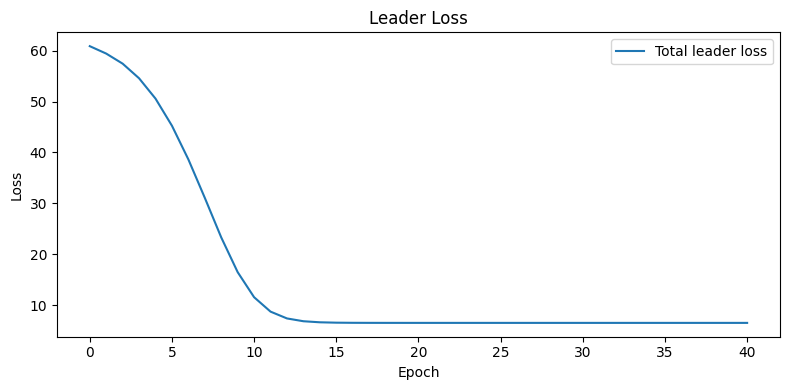

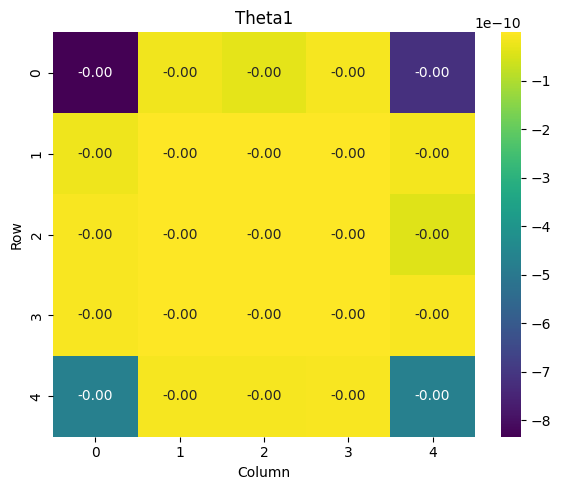

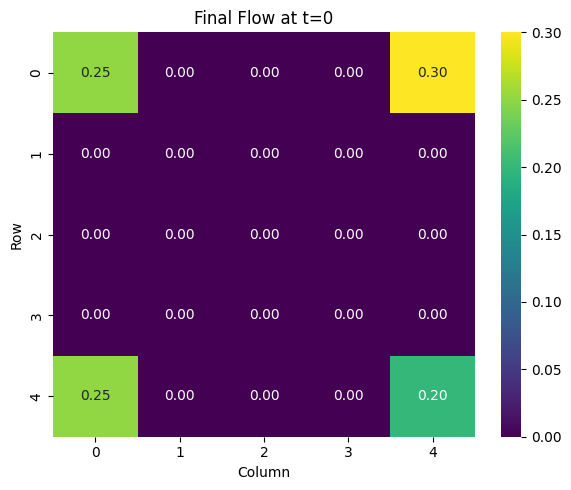

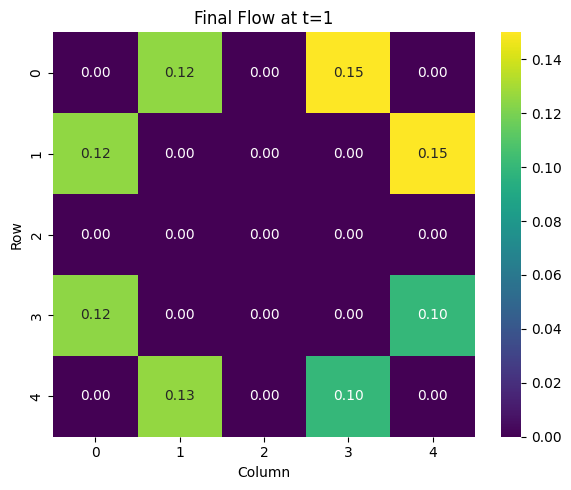

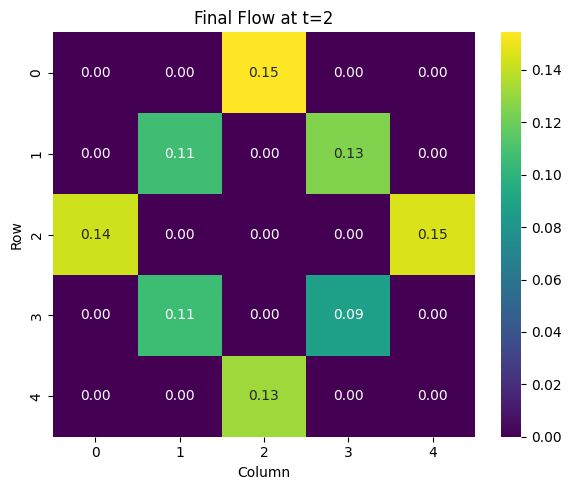

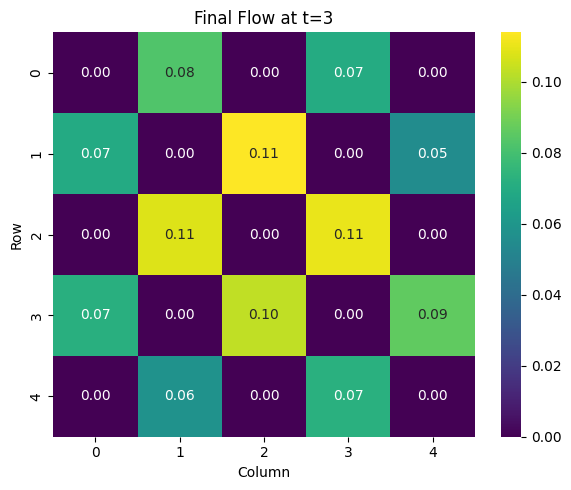

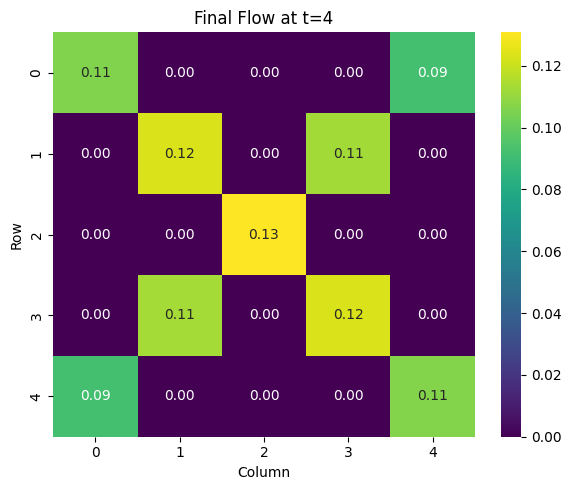

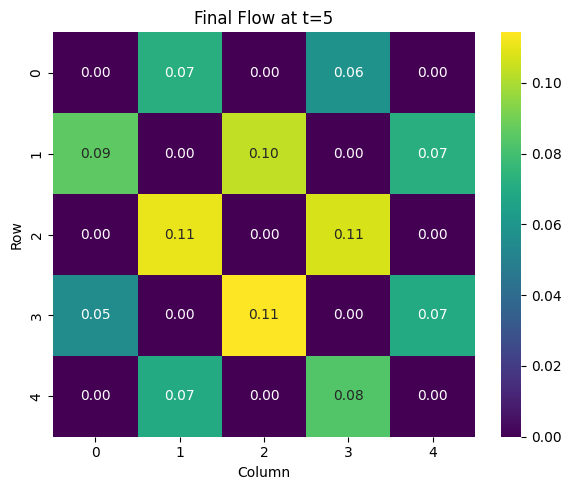

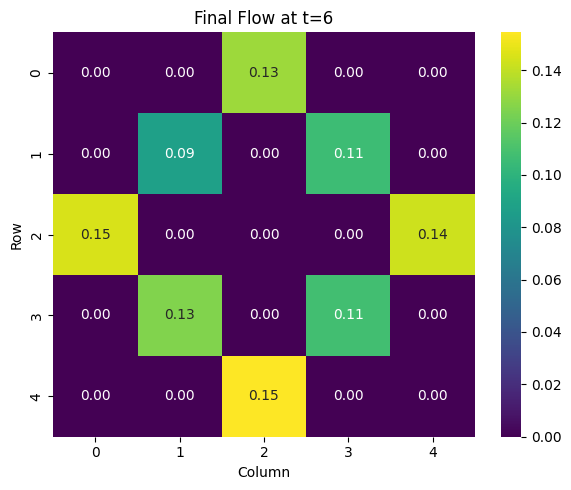

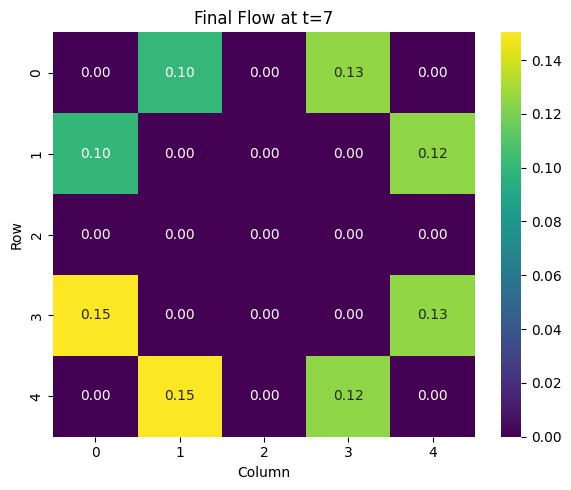

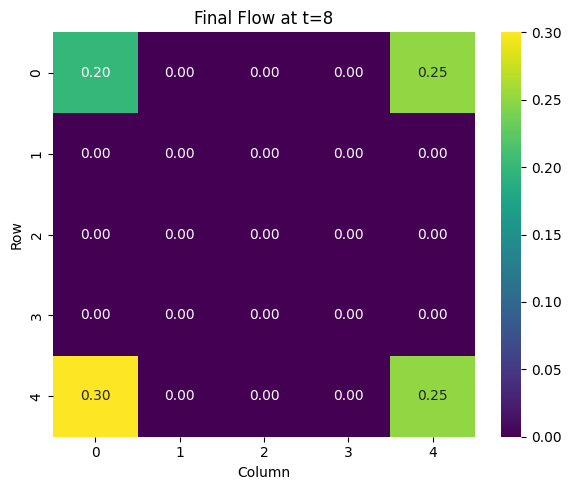

In [7]:
final_flow_4, losses_4, theta1_4 = run_amid_multigroup()

plot_heatmap(theta1_4[0].cpu().detach().numpy(), title="Theta1", xlabel="Column", ylabel="Row")


for i in range(final_flow_4.shape[0]):
    plot_heatmap(final_flow_4[i].cpu().detach().numpy(), title=f"Final Flow at t={i}", xlabel="Column", ylabel="Row")

In [ ]:
final_flow_3, losses_3, theta1_3 = run_amid_multigroup()

plot_heatmap(theta1_3[0].cpu().detach().numpy(), title="Theta1", xlabel="Column", ylabel="Row")  


for i in range(final_flow_3.shape[0]):
    plot_heatmap(final_flow_3[i].cpu().detach().numpy(), title=f"Final Flow at t={i}", xlabel="Column", ylabel="Row")

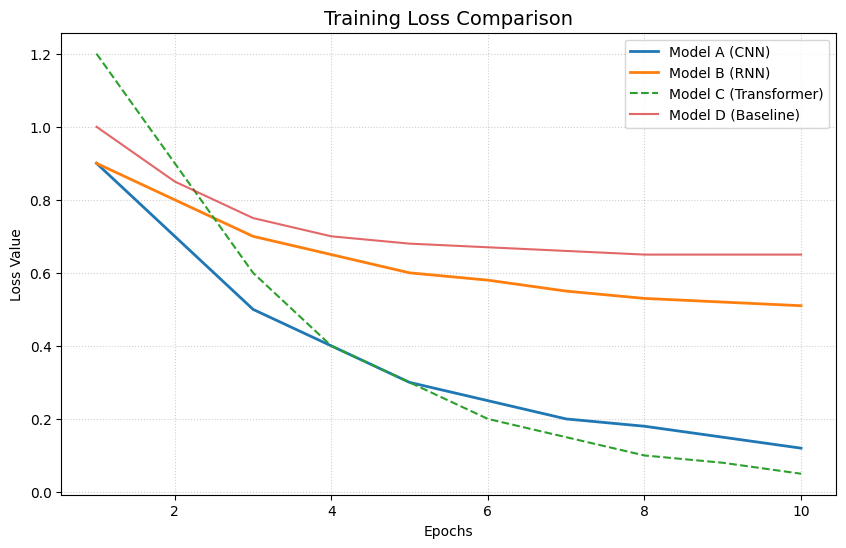

In [ ]:
import matplotlib.pyplot as plt

# Dummy data: Replace these with your actual loss lists
epochs = range(1, 11)
loss_1 = 
loss_2 = 
loss_3 = 
loss_4 = 

plt.figure(figsize=(10, 6))

# Plotting each line
plt.plot(epochs, loss_1, label='1 Group', linewidth=2)
plt.plot(epochs, loss_2, label='2 Groups', linewidth=2)
plt.plot(epochs, loss_3, label='3 Groups', linestyle='--')
plt.plot(epochs, loss_4, label='4 Groups', alpha=0.7)

# Formatting the graph
plt.title('Training Loss Comparison', fontsize=14)
plt.xlabel('Epochs')
plt.ylabel('Loss Value')
plt.legend() # This is crucial to identify which line is which
plt.grid(True, linestyle=':', alpha=0.6)

plt.show()